In [61]:
import yfinance as yf
import pandas as pd
import numpy as np

In [62]:
from datetime import *

# Getting the stock data from YFinance
# Ask the user for a ticker
symbol = input("Enter a stock symbol (e.g. AAPL, TSLA, SPY): ").strip().upper()

# Getting the stock data from YFinance
end_date = date.today() + timedelta(days=1)
start_date = date.today() - timedelta(days=(5 * 365) + 300)
stock_data = yf.download(symbol, start=start_date, end=end_date, auto_adjust=True)


if stock_data.empty:
    raise ValueError(f"No data found for '{symbol}'. Check the symbol and try again.")

stock_data = stock_data.reset_index()
stock_data = stock_data[["Date","Open","Close"]]
stock_data.columns = stock_data.columns.get_level_values(0)

Enter a stock symbol (e.g. AAPL, TSLA, SPY): NVDA


[*********************100%***********************]  1 of 1 completed


In [63]:
stock_data["MA200"] = stock_data["Close"].rolling(200).mean()
stock_data["MA50"] = stock_data["Close"].rolling(50).mean()

In [64]:
stock_data.columns

Index(['Date', 'Open', 'Close', 'MA200', 'MA50'], dtype='object', name='Price')

In [65]:
# Removing the first 200 days
stock_data_trimmed = stock_data.dropna(subset=['MA200'], ignore_index=True,how="all")

In [66]:
# Above checks when 50-day-avg is more than 200-day-avg
stock_data_trimmed["above"] = stock_data_trimmed['MA50'] > stock_data_trimmed['MA200']

# This column checks if previous day was above or not
stock_data_trimmed["was_above"] = stock_data_trimmed["above"].shift(1)

# Signal Column will tell us about golden cross and death cross
stock_data_trimmed["Signal"] = 0

# Golden cross
stock_data_trimmed.loc[(stock_data_trimmed["above"] == True) & (stock_data_trimmed["was_above"] == False), "Signal"] = 1

# Death cross
stock_data_trimmed.loc[(stock_data_trimmed["above"] == False) & (stock_data_trimmed["was_above"] == True), "Signal"] = -1



/tmp/ipykernel_1980/3462601566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data_trimmed["above"] = stock_data_trimmed['MA50'] > stock_data_trimmed['MA200']
/tmp/ipykernel_1980/3462601566.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data_trimmed["was_above"] = stock_data_trimmed["above"].shift(1)
/tmp/ipykernel_1980/3462601566.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [67]:
# Logic of the strategy
capital = 10000
shares = 0
# pending = 1 means that a buy order is left
# pending = -1 means that a sell order is left
pending = 0
buy_price = None
buy_date = None

# To store portfolio value after each day
portfolio_values = []
trades = []
buy_price = None


for i in range(len(stock_data_trimmed)):
  date_i = stock_data_trimmed["Date"].iloc[i]
  open = stock_data_trimmed["Open"].iloc[i]
  close = stock_data_trimmed["Close"].iloc[i]

  if pending == 1 and shares == 0:
    shares = capital/open
    buy_price = open
    buy_date = date_i
    capital = 0
    pending = 0

  elif pending == -1 and shares > 0:
    capital += shares * open
    trades.append({"buy_date":buy_date,"buy_price":buy_price,"sell_date":date_i,"sell_price":open})
    shares = 0
    pending = 0

  portfolio_values.append(capital + shares * close)

  # To decide what action to take next day we update pending today
  pending = stock_data_trimmed["Signal"].iloc[i]

# If the person has not sold till last day, stocks are automatically sold on last day
trades.append({"buy_date": buy_date, "buy_price": buy_price,"sell_date": stock_data_trimmed["Date"].iloc[-1],"sell_price": stock_data_trimmed["Close"].iloc[-1]})


stock_data_trimmed["Portfolio_value"] = portfolio_values


# Buy and hold strategy

bh_shares = 10000 / stock_data_trimmed["Open"].iloc[0]
stock_data_trimmed["Buy&Hold"] = bh_shares * stock_data_trimmed["Close"]


/tmp/ipykernel_1980/4125403082.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data_trimmed["Portfolio_value"] = portfolio_values
/tmp/ipykernel_1980/4125403082.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data_trimmed["Buy&Hold"] = bh_shares * stock_data_trimmed["Close"]


                  Crossover Strategy   Buy & Hold
Final Value ($)           90261.0088  108347.4597
Total Return (%)            802.6101     983.4746
CAGR (%)                     54.9490      60.6856
Max Drawdown (%)            -28.4079     -66.3351
Win Rate (%)                100.0000          NaN
Sharpe Ratio                  1.3248       1.1743

Trades:
    buy_date   buy_price  sell_date  sell_price
0 2023-01-25   18.849978 2025-03-21  116.645825
1 2025-06-30  158.012486 2026-10-01  230.479996






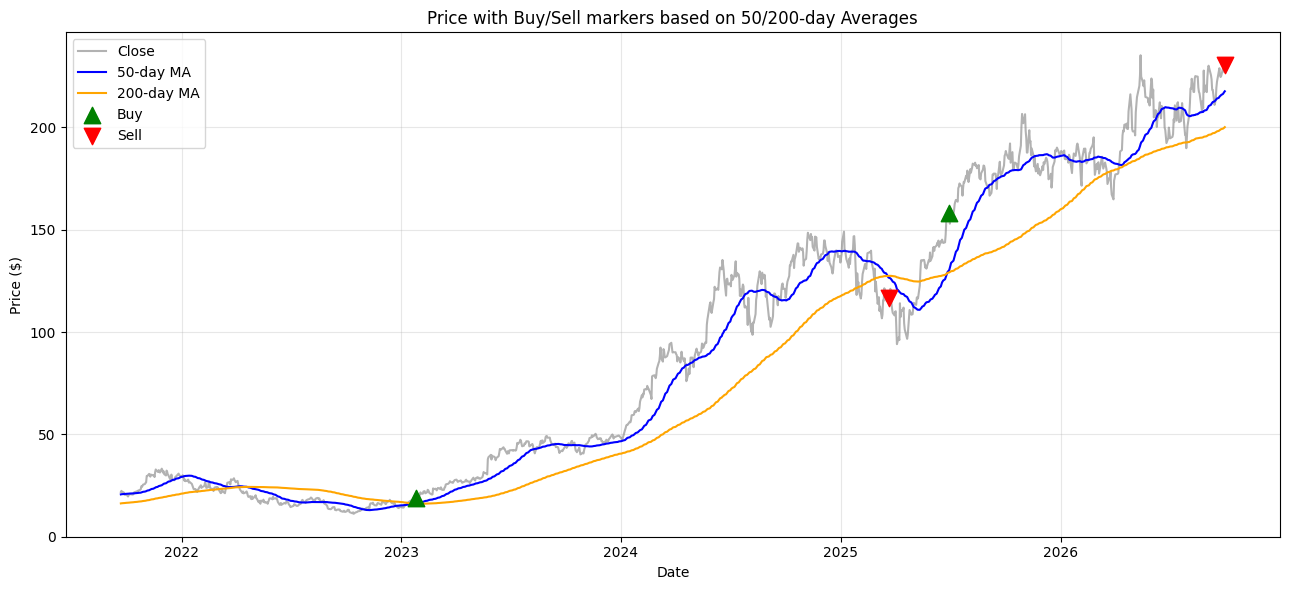

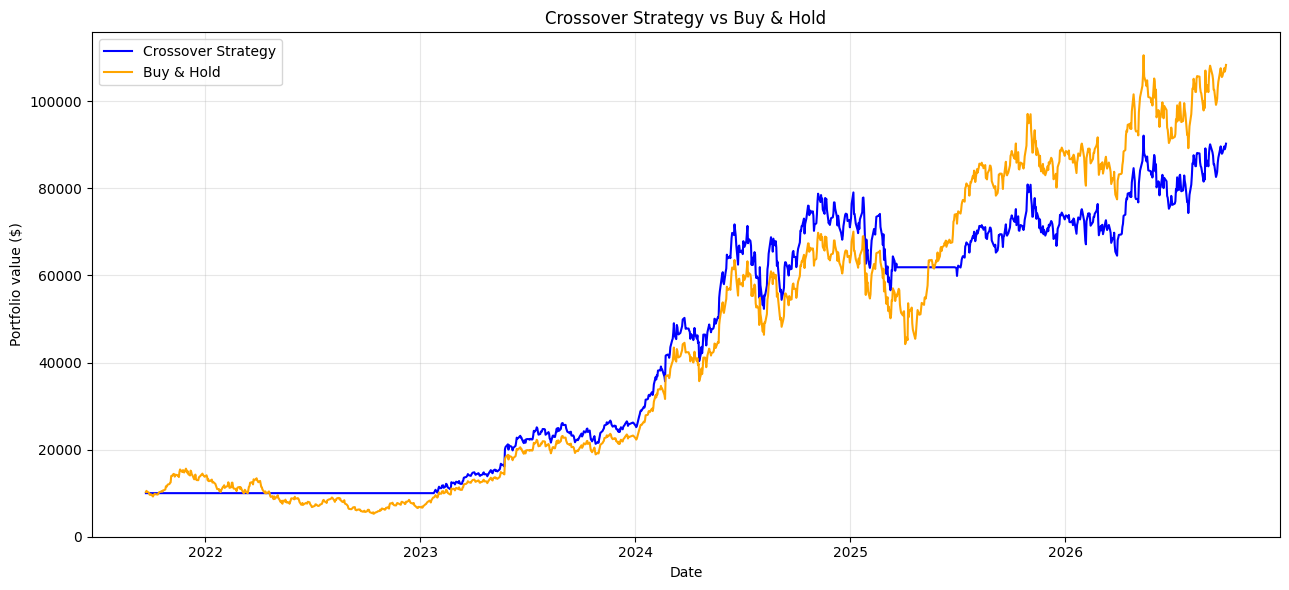

In [73]:
import matplotlib.pyplot as plt


initial_capital = 10000
def metrics(series, dates, trades=None):
    final = series.iloc[-1]
    total_return = (final / initial_capital - 1) * 100

    years = (dates.iloc[-1] - dates.iloc[0]).days / 365.25
    cagr = ((final / initial_capital) ** (1 / years) - 1) * 100

    max_dd = ((series / series.cummax()) - 1).min() * 100

    # Daily returns
    values = pd.concat([pd.Series([initial_capital]), series.reset_index(drop=True)])
    daily_returns = values.pct_change().dropna()
    if daily_returns.std() > 0:
        sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
    else:
        sharpe = np.nan

    win_rate = np.nan
    if trades:
        wins = sum(t["sell_price"] > t["buy_price"] for t in trades)
        win_rate = wins / len(trades) * 100

    return {"Final Value ($)": final,
            "Total Return (%)": total_return,
            "CAGR (%)": cagr,
            "Max Drawdown (%)": max_dd,
            "Win Rate (%)": win_rate,
            "Sharpe Ratio": sharpe}


dates = stock_data_trimmed["Date"]
strategy_metrics = metrics(stock_data_trimmed["Portfolio_value"], dates, trades)
buyhold_metrics  = metrics(stock_data_trimmed["Buy&Hold"], dates)

results = pd.DataFrame({"Crossover Strategy": strategy_metrics,
                        "Buy & Hold": buyhold_metrics})
print(results.round(4))
print("\nTrades:")
print(pd.DataFrame(trades))

print("\n"*3)

d = stock_data_trimmed

buys  = [(t["buy_date"], t["buy_price"]) for t in trades]
sells = [(t["sell_date"], t["sell_price"]) for t in trades]

# Graph 1: Stock price with all the Buy & Sell markers
plt.figure(figsize=(13, 6))
plt.plot(d["Date"], d["Close"], label="Close", color="gray", alpha=0.6)
plt.plot(d["Date"], d["MA50"], label="50-day MA", color="blue")
plt.plot(d["Date"], d["MA200"], label="200-day MA", color="orange")
if buys:
    plt.scatter(*zip(*buys), marker="^", color="green", s=140, zorder=5, label="Buy")
if sells:
    plt.scatter(*zip(*sells), marker="v", color="red", s=140, zorder=5, label="Sell")
plt.title("Price with Buy/Sell markers based on 50/200-day Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Graph 2: Our strategy vs Buy&hold strategy
plt.figure(figsize=(13, 6))
plt.plot(d["Date"], d["Portfolio_value"], label="Crossover Strategy", color="blue")
plt.plot(d["Date"], d["Buy&Hold"], label="Buy & Hold", color="orange")
plt.title("Crossover Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()